# Lab 7 - Processamento morfológico de imagens

### 3) Atividades práticas experimentais

3a) Elabore um programa para realizar as operações de EROSÃO, DILATAÇÃO, ABERTURA,
e FECHAMENTO, sobre as imagens em grupo dos integrantes da equipe bem como nos
avatares, e apresente os resultados. Elabore uma análise detalhada de cada imagem,
experimentado diversos tamanhos (3x3 até 21x21) de Elemento Estruturante – KERNEL - e
compare-as entre si, quanto ao aspecto visual (filtragem, aparência, representação, etc) da
imagens resultantes. Lembre-se de binarizar as imagens antes da aplicação dos
operadores. Assim, dentro desta análise, discuta se a binarização influiu no resultado e
qual método foi mais interessante para sua aplicação.

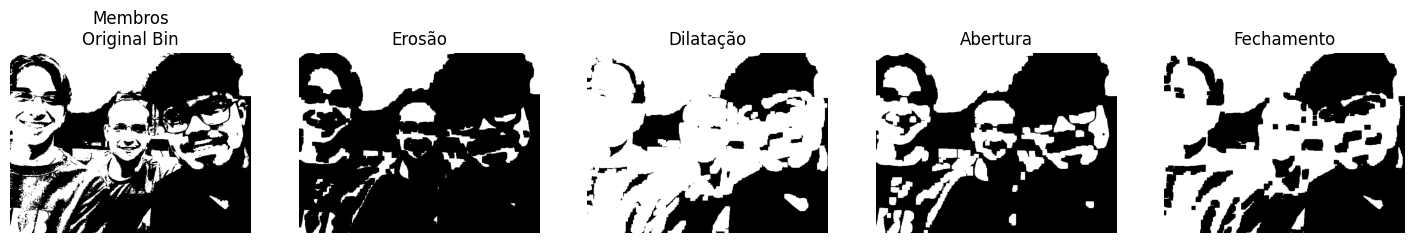

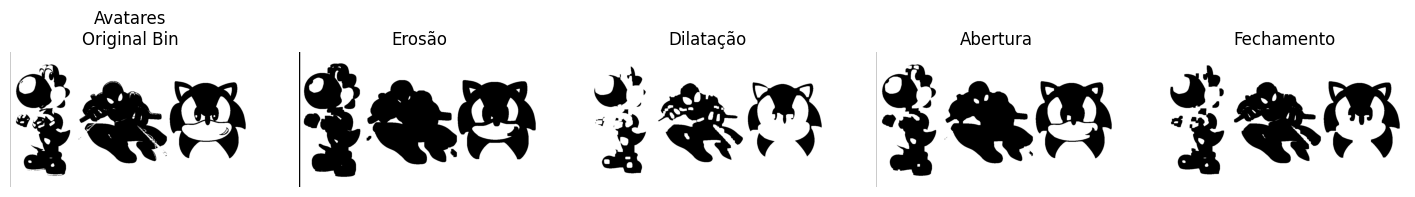

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import *

mm.install()

## Ex 3a

img_membros = mm.read('images/alunos.png') 
img_avatares = mm.read('images/avatares.png')

def operacoes_edaf(img_input, titulo_prefixo):
    img_rgb = mm.color(img_input)
    img_gray = mm.gray(img_rgb)

    ## Binarização da imagem
    ## Pixeis com valor maior que 0 serão considerados 1
    
    img_bin = mm.threshold(img_gray, 0)

    kernel = np.ones((11,11), np.uint8)
    
    operacoes = {
        "Erosão": mm.ero(img_bin, kernel),
        "Dilatação": mm.dil(img_bin, kernel),
        "Abertura": mm.open(img_bin, kernel),
        "Fechamento": mm.close(img_bin, kernel)
    }

    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 5, 1)
    plt.imshow(img_bin, cmap='gray')
    plt.title(f"{titulo_prefixo}\nOriginal Bin")
    plt.axis('off')

    for i, (nome, resultado) in enumerate(operacoes.items(), 2):
        plt.subplot(1, 5, i)
        plt.imshow(resultado, cmap='gray')
        plt.title(f"{nome}")
        plt.axis('off')
    
    plt.show()

operacoes_edaf(img_membros, "Membros")
operacoes_edaf(img_avatares, "Avatares")

(3.b). Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações de Extração de Fronteiras (Gradiente Morfológico), mostrando na tela em tempo
real lado-a-lado a imagem original e a imagem extraída, permitindo ao operador escolher
– via teclado – a extração com diversos tamanhos de kernel. Grave um video demonstrativocom os integrantes da equipe utilizando este programa com a webcam. Elabore uma
análise detalhada e explique os artefatos ocorridos.

In [ ]:
import cv2
import numpy as np
from morph import mm

## Ex 3b

cap = cv2.VideoCapture(0)
k_size = 3
gravando = False
out = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = mm.color(frame)
    img_gray = mm.gray(img_rgb)
    img_bin = mm.threshold(img_gray, 0)
    
    kernel = np.ones((k_size, k_size), np.uint8)
    fronteira = mm.gradm(img_bin, kernel)
    
    fronteira_bgr = cv2.cvtColor(fronteira, cv2.COLOR_GRAY2BGR)
    resultado = cv2.hconcat([frame, fronteira_bgr])
    
    cv2.putText(resultado, f"Kernel: {k_size}x{k_size}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    if gravando and out is not None:
        out.write(resultado)

    cv2.imshow('Lab7 - Gradiente Morfologico', resultado)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('s'):
        gravando = not gravando
        if gravando:
            h, w, _ = resultado.shape
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
            out = cv2.VideoWriter('video_saida.avi', fourcc, 20.0, (w, h))
        else:
            out.release()
    elif key == ord('1'): k_size = 3
    elif key == ord('2'): k_size = 7
    elif key == ord('3'): k_size = 11
    elif key == ord('4'): k_size = 15
    elif key == ord('5'): k_size = 21

cap.release()
if out is not None:
    out.release()
cv2.destroyAllWindows()

(4.a). Elabore um programa para aplicar os operadores morfológicos imagens do seu
trabalho final, explicando o objetivo deste procedimento dentro do contexto da aplicação.

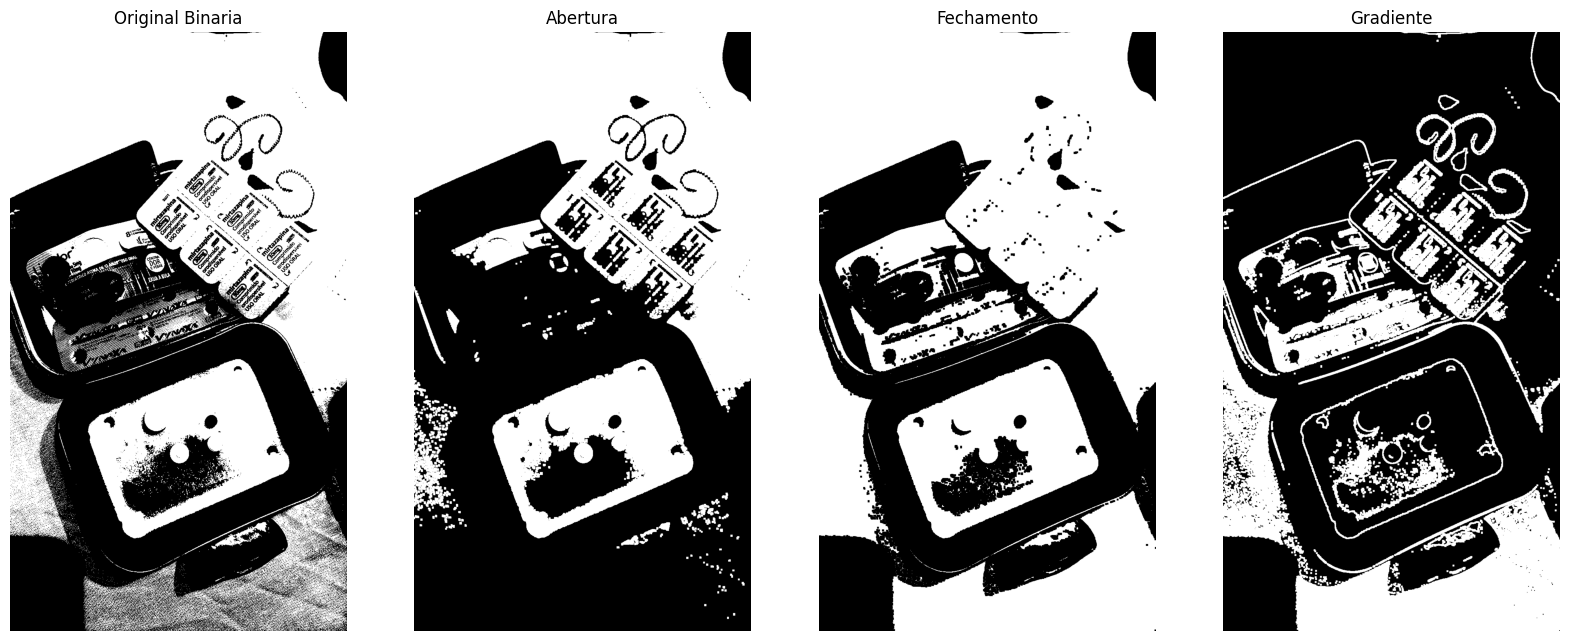

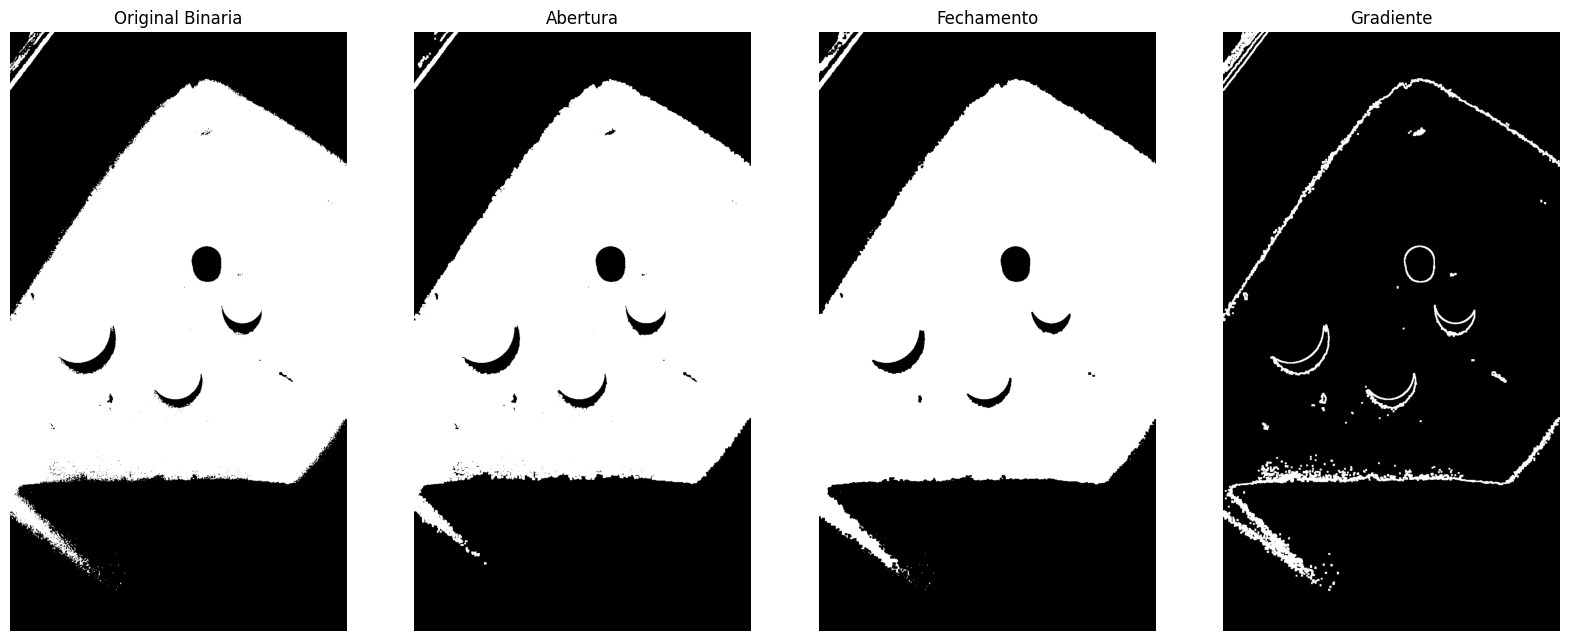

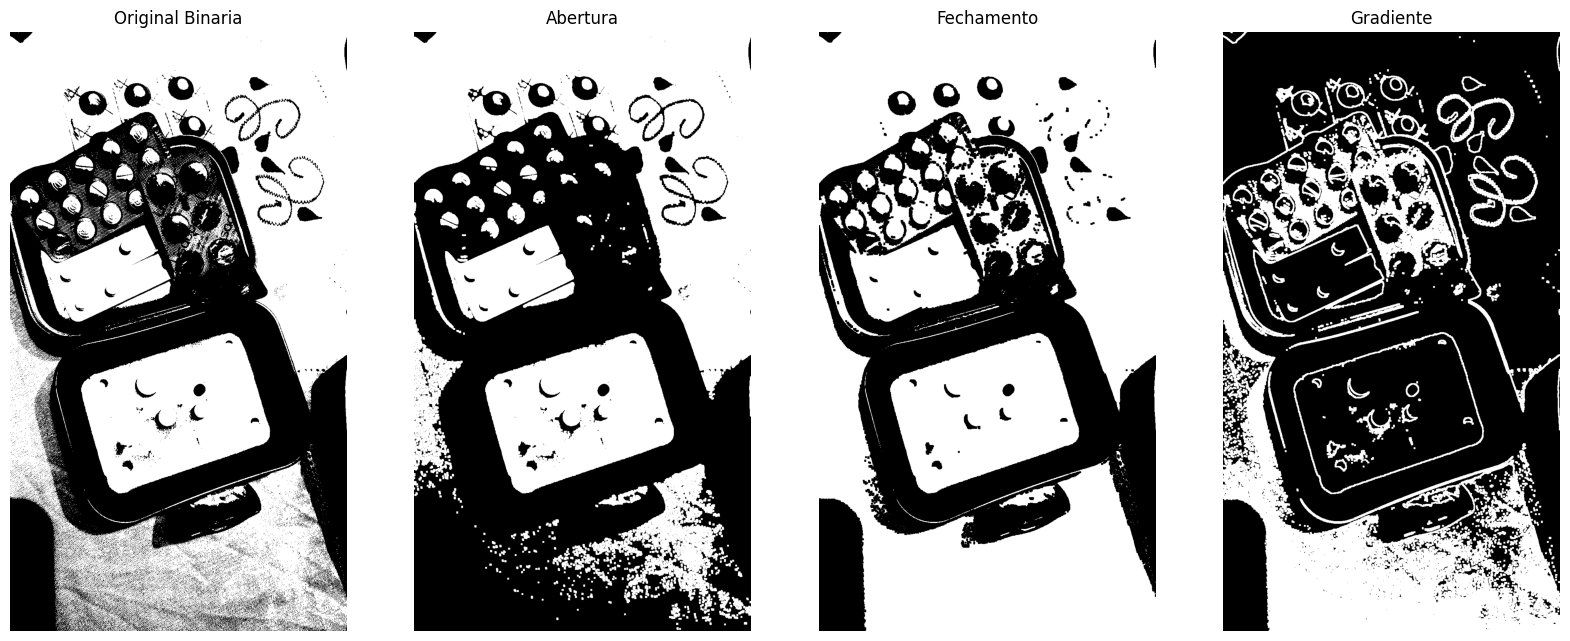

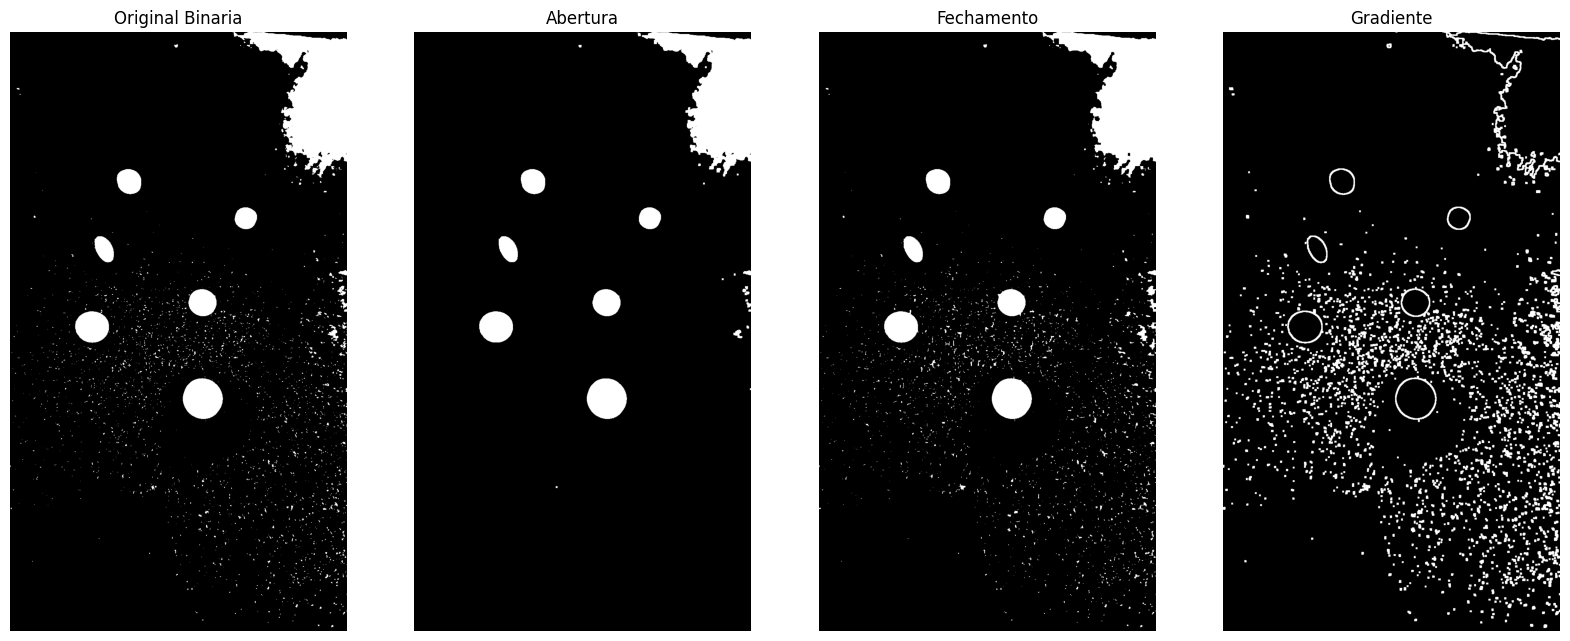

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import mm
import os

def processar_projeto_final(img):
    img_rgb = mm.color(img)
    img_gray = mm.gray(img_rgb)
    img_bin = mm.threshold(img_gray, 0)

    kernel = np.ones((5,5), np.uint8)

    abertura = mm.open(img_bin, kernel)
    fechamento = mm.close(img_bin, kernel)
    gradiente = mm.gradm(img_bin, kernel)

    imagens = [img_bin, abertura, fechamento, gradiente]
    titulos = ['Original Binaria', 'Abertura', 'Fechamento', 'Gradiente']

    plt.figure(figsize=(20, 8))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(imagens[i], cmap='gray')
        plt.title(titulos[i])
        plt.axis('off')
    plt.show()

diretorio = 'images'
for arquivo in sorted(os.listdir(diretorio)):
    if arquivo.lower().endswith(('.jpeg', '.jpg', '.png')):
        img_projeto = mm.read(os.path.join(diretorio, arquivo))
        processar_projeto_final(img_projeto)